1. Load Model & Artifacts 

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings, os, time
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'axes.titlesize':11,'axes.labelsize':10})

# ── Load saved artifacts
MODEL_DIR = 'tuned_models'
PREP_DIR  = 'preprocessed'
X_test_scaled = np.load(f'{PREP_DIR}/X_test_scaled.npy')
y_test_multi  = np.load(f'{PREP_DIR}/y_test_multi.npy')
# Load the unscaled version
X_test_raw = np.load('preprocessed/X_test.npy')   # unscaled

X_test_raw_df = pd.DataFrame(X_test_raw, columns=FEATURE_COLS)
model   = joblib.load(f'{MODEL_DIR}/tuned_random_forest.pkl')
scaler  = joblib.load(f'{PREP_DIR}/robust_scaler.pkl')
le      = joblib.load(f'{PREP_DIR}/label_encoder.pkl')
feat_df = pd.read_csv(f'{PREP_DIR}/feature_names.csv')
FEATURE_COLS = feat_df.iloc[:, 0].tolist()

CLASS_NAMES = [str(c) for c in le.classes_]
N_CLASSES   = len(CLASS_NAMES)

print('✅ Artifacts loaded successfully')
print(f'   Model          : Tuned Random Forest')
print(f'   Classes        : {N_CLASSES}')
print(f'   Features       : {len(FEATURE_COLS)}')
print(f'   Class names    : {CLASS_NAMES}')


✅ Artifacts loaded successfully
   Model          : Tuned Random Forest
   Classes        : 15
   Features       : 69
   Class names    : ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack_Brute Force', 'Web Attack_Sql Injection', 'Web Attack_XSS']


2. Preprocessing Function

Applies the exact same preprocessing steps used during training:
    
cleaning → feature engineering → log transforms → scaling.

In [11]:
def preprocess_input(df_input, feature_cols, scaler,
                     log_features=None, verbose=True):
    """
    Preprocess raw network flow data for inference.

    Parameters
    ----------
    df_input     : pd.DataFrame — raw network flow data
    feature_cols : list         — expected feature column names
    scaler       : fitted RobustScaler
    log_features : list         — features that need log1p transform
    verbose      : bool         — print processing steps

    Returns
    -------
    X_scaled : np.ndarray — model-ready feature matrix
    """
    df = df_input.copy()

    if verbose:
        print(f'Input shape: {df.shape}')

    # ── Step 1: Strip column name whitespace
    df.columns = df.columns.str.strip()

    # ── Step 2: Drop known non-feature columns if present
    DROP_COLS = ['Flow ID','Source IP','Destination IP',
                 'Timestamp','source_file','Label',
                 'y_binary','y_multi','Is_Attack',
                 'Fwd Header Length.1', 'Protocol_Name']
    df.drop(columns=[c for c in DROP_COLS if c in df.columns],
            inplace=True)

    # ── Step 3: Replace Inf with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # ── Step 4: Feature engineering (match training)
    def safe(col):
        return df[col] if col in df.columns else pd.Series(0, index=df.index)

    fwd = safe('Total Fwd Packets')
    bwd = safe('Total Backward Packets')
    df['Fwd_Bwd_Pkt_Ratio']  = fwd / (fwd + bwd + 1)
    df['Bytes_Per_Packet']   = safe('Flow Bytes/s') / (safe('Flow Packets/s') + 1)
    df['Header_Payload_Ratio'] = safe('Fwd Header Length') / \
                                  (safe('Total Length of Fwd Packets') + 1)
    df['IAT_Fwd_Bwd_Ratio']  = safe('Fwd IAT Mean') / (safe('Bwd IAT Mean') + 1)
    df['Pkt_Size_Asymmetry'] = safe('Fwd Packet Length Mean') - \
                                safe('Bwd Packet Length Mean')
    df['Win_Size_Ratio']     = safe('Init_Win_bytes_forward') / \
                                (safe('Init_Win_bytes_backward').abs() + 1)
    for flag, src in [('Has_SYN','SYN Flag Count'),
                      ('Has_RST','RST Flag Count'),
                      ('Has_FIN','FIN Flag Count')]:
        df[flag] = (safe(src) > 0).astype(int)

    # ── Step 5: Log transforms
    if log_features:
        for feat in log_features:
            orig = feat.replace('log_', '')
            if orig in df.columns:
                df[feat] = np.log1p(df[orig].clip(lower=0))

    # ── Step 6: Fill any remaining NaN with 0
    df.fillna(0, inplace=True)

    # ── Step 7: Align columns to training feature set
    missing_cols = set(feature_cols) - set(df.columns)
    extra_cols   = set(df.columns) - set(feature_cols)

    if verbose and missing_cols:
        print(f'  ⚠️  Missing columns filled with 0: {missing_cols}')
    if verbose and extra_cols:
        print(f'  ℹ️  Extra columns dropped: {len(extra_cols)}')

    # Add missing columns as 0
    for col in missing_cols:
        df[col] = 0

    # Select and reorder to match training
    X = df[feature_cols].values

    # ── Step 8: Scale
    X_scaled = scaler.transform(X)

    if verbose:
        print(f'Output shape : {X_scaled.shape}')
        print(f'✅ Preprocessing complete')

    return X_scaled

print('✅ preprocess_input() defined')


✅ preprocess_input() defined


3. Prediction Function

The main inference function — takes raw data, returns predictions with confidence scores.

In [12]:
def predict_traffic(df_input, model, scaler, le,
                    feature_cols, log_features=None,
                    threshold=0.5, verbose=True):
    """
    Predict attack type for raw network flow data.

    Parameters
    ----------
    df_input     : pd.DataFrame — raw network flows
    model        : fitted classifier
    scaler       : fitted RobustScaler
    le           : fitted LabelEncoder
    feature_cols : list of expected feature names
    log_features : list of log-transformed feature names
    threshold    : float — min confidence to flag as ATTACK
    verbose      : bool  — print prediction summary

    Returns
    -------
    results_df : pd.DataFrame with columns:
                 Predicted_Label, Confidence, Is_Attack, Risk_Level
    """
    start = time.time()

    # ── Preprocess
    X_scaled = preprocess_input(
        df_input, feature_cols, scaler, log_features, verbose
    )

    # ── Predict
    y_pred      = model.predict(X_scaled)
    y_prob      = model.predict_proba(X_scaled)
    confidence  = y_prob.max(axis=1) * 100

    # ── Decode labels
    pred_labels = le.inverse_transform(y_pred)
    is_attack   = (pred_labels != 'BENIGN').astype(int)

    # ── Risk level based on confidence
    def risk_level(label, conf):
        if label == 'BENIGN':
            return 'SAFE'
        elif conf >= 90:
            return '🔴 HIGH'
        elif conf >= 70:
            return '🟠 MEDIUM'
        else:
            return '🟡 LOW'

    risk = [risk_level(l, c)
            for l, c in zip(pred_labels, confidence)]

    elapsed = time.time() - start

    # ── Build results DataFrame
    results_df = pd.DataFrame({
        'Predicted_Label': pred_labels,
        'Confidence (%)'  : confidence.round(2),
        'Is_Attack'       : is_attack,
        'Risk_Level'      : risk,
    })

    # Add per-class probabilities
    prob_df = pd.DataFrame(
        y_prob * 100,
        columns=[f'P({c})' for c in le.classes_]
    ).round(2)
    results_df = pd.concat([results_df.reset_index(drop=True),
                            prob_df.reset_index(drop=True)], axis=1)

    if verbose:
        n_attacks = is_attack.sum()
        n_benign  = len(is_attack) - n_attacks
        print(f'\n--- Prediction Summary ---')
        print(f'  Total flows  : {len(results_df):,}')
        print(f'  Benign       : {n_benign:,}  ({n_benign/len(results_df)*100:.1f}%)')
        print(f'  Attacks      : {n_attacks:,}  ({n_attacks/len(results_df)*100:.1f}%)')
        print(f'  Inference time : {elapsed*1000:.1f} ms')
        if n_attacks > 0:
            print(f'\n  Attack breakdown:')
            atk = results_df[results_df['Is_Attack']==1]\
                    ['Predicted_Label'].value_counts()
            for label, cnt in atk.items():
                print(f'    {str(label):<40}: {cnt:,}')

    return results_df

print('✅ predict_traffic() defined')


✅ predict_traffic() defined


4. Single Sample Prediction

Test the pipeline on a single network flow — simulates real-time inference.

In [13]:
# ── Pull one real sample from test set for demo
# Recreate test DataFrame with proper column names
X_test_df = pd.DataFrame(
    X_test_scaled if isinstance(X_test_scaled, np.ndarray)
    else X_test_scaled.values,
    columns=FEATURE_COLS
)

# Take one benign sample
benign_idx  = np.where(y_test_multi == le.transform(['BENIGN'])[0])[0][0]
single_benign = X_test_df.iloc[[benign_idx]].copy()

# Take one attack sample
attack_idx  = np.where(y_test_multi != le.transform(['BENIGN'])[0])[0][0]
single_attack = X_test_df.iloc[[attack_idx]].copy()

print('=== Testing on a BENIGN sample ===')
result_benign = predict_traffic(
    single_benign, model, scaler, le,
    FEATURE_COLS, verbose=True
)
print('\nResult:')
print(result_benign[['Predicted_Label','Confidence (%)','Is_Attack','Risk_Level']])


=== Testing on a BENIGN sample ===
Input shape: (1, 69)
  ℹ️  Extra columns dropped: 1
Output shape : (1, 69)
✅ Preprocessing complete

--- Prediction Summary ---
  Total flows  : 1
  Benign       : 1  (100.0%)
  Attacks      : 0  (0.0%)
  Inference time : 70.0 ms

Result:
  Predicted_Label  Confidence (%)  Is_Attack Risk_Level
0          BENIGN            82.0          0       SAFE


In [14]:
print('=== Testing on an ATTACK sample ===')
result_attack = predict_traffic(
    single_attack, model, scaler, le,
    FEATURE_COLS, verbose=True
)
print('\nResult:')
print(result_attack[['Predicted_Label','Confidence (%)','Is_Attack','Risk_Level']])

# Actual label for verification
actual = le.inverse_transform([y_test_multi[attack_idx]])[0]
print(f'\nActual label : {actual}')
print(f'Predicted    : {result_attack["Predicted_Label"].iloc[0]}')
print(f'Correct      : {actual == result_attack["Predicted_Label"].iloc[0]}')


=== Testing on an ATTACK sample ===
Input shape: (1, 69)
  ℹ️  Extra columns dropped: 1
Output shape : (1, 69)
✅ Preprocessing complete

--- Prediction Summary ---
  Total flows  : 1
  Benign       : 1  (100.0%)
  Attacks      : 0  (0.0%)
  Inference time : 76.8 ms

Result:
  Predicted_Label  Confidence (%)  Is_Attack Risk_Level
0          BENIGN            94.0          0       SAFE

Actual label : DDoS
Predicted    : BENIGN
Correct      : False


5. Batch Prediction

Run inference on multiple flows at once — simulates processing a capture window.

In [15]:
# ── Sample 500 flows from test set (mix of benign + attack)
np.random.seed(42)
batch_idx = np.random.choice(len(X_test_df), size=500, replace=False)
X_batch   = X_test_df.iloc[batch_idx].copy()
y_batch   = y_test_multi[batch_idx]

print(f'Batch size: {len(X_batch):,} flows')
print('Running batch inference...\n')

batch_results = predict_traffic(
    X_batch, model, scaler, le,
    FEATURE_COLS, verbose=True
)


Batch size: 500 flows
Running batch inference...

Input shape: (500, 69)
  ℹ️  Extra columns dropped: 1
Output shape : (500, 69)
✅ Preprocessing complete

--- Prediction Summary ---
  Total flows  : 500
  Benign       : 500  (100.0%)
  Attacks      : 0  (0.0%)
  Inference time : 85.3 ms


In [16]:
# ── Evaluate batch accuracy
actual_labels  = le.inverse_transform(y_batch)
pred_labels    = batch_results['Predicted_Label'].values
correct        = (actual_labels == pred_labels).sum()

print(f'\nBatch Accuracy : {correct}/{len(y_batch)} = {correct/len(y_batch)*100:.2f}%')

# ── Misclassified flows
wrong_idx = np.where(actual_labels != pred_labels)[0]
print(f'Misclassified  : {len(wrong_idx)} flows')
if len(wrong_idx) > 0:
    print('\nMisclassification breakdown:')
    wrong_df = pd.DataFrame({
        'Actual'   : actual_labels[wrong_idx],
        'Predicted': pred_labels[wrong_idx],
        'Confidence': batch_results['Confidence (%)'].values[wrong_idx]
    })
    print(wrong_df.groupby(['Actual','Predicted'])
                  .size()
                  .reset_index(name='Count')
                  .sort_values('Count', ascending=False)
                  .to_string(index=False))



Batch Accuracy : 409/500 = 81.80%
Misclassified  : 91 flows

Misclassification breakdown:
          Actual Predicted  Count
            DDoS    BENIGN     34
        DoS Hulk    BENIGN     29
        PortScan    BENIGN     20
   DoS slowloris    BENIGN      3
   DoS GoldenEye    BENIGN      2
DoS Slowhttptest    BENIGN      2
     SSH-Patator    BENIGN      1


6. Predict from CSV File 

Load a raw CSV file of network flows and run predictions — closest to real deployment.

In [17]:
def predict_from_csv(csv_path, model, scaler, le,
                     feature_cols, log_features=None,
                     save_output=True):
    """
    Load a raw CICIDS2017-format CSV and predict attack types.

    Parameters
    ----------
    csv_path     : str  — path to CSV file
    save_output  : bool — save predictions to CSV

    Returns
    -------
    results_df : pd.DataFrame
    """
    print(f'Loading: {csv_path}')
    df_raw = pd.read_csv(csv_path, encoding='utf-8', low_memory=False)
    df_raw.columns = df_raw.columns.str.strip()

    # Save Label if present (for evaluation)
    true_labels = None
    if 'Label' in df_raw.columns:
        true_labels = df_raw['Label'].str.strip().values
        print(f'True labels found — will evaluate after prediction')

    print(f'Loaded {len(df_raw):,} flows')

    # Run inference
    results = predict_traffic(
        df_raw, model, scaler, le,
        feature_cols, log_features, verbose=True
    )

    # Evaluate if true labels available
    if true_labels is not None:
        from sklearn.metrics import accuracy_score, f1_score
        pred = results['Predicted_Label'].values
        try:
            y_true_enc = le.transform(true_labels)
            y_pred_enc = le.transform(pred)
            acc  = accuracy_score(y_true_enc, y_pred_enc)
            f1m  = f1_score(y_true_enc, y_pred_enc,
                            average='macro', zero_division=0)
            print(f'\n  Evaluation vs true labels:')
            print(f'  Accuracy : {acc*100:.3f}%')
            print(f'  Macro F1 : {f1m*100:.3f}%')
        except Exception as e:
            print(f'  Could not evaluate: {e}')

    # Save predictions
    if save_output:
        out_path = csv_path.replace('.csv', '_predictions.csv')
        results[['Predicted_Label','Confidence (%)','Is_Attack','Risk_Level']]\
               .to_csv(out_path, index=False)
        print(f'\n✅ Predictions saved to: {out_path}')

    return results

print('✅ predict_from_csv() defined')
print('\nUsage example:')
print('  results = predict_from_csv(')
print('      csv_path="path/to/new_traffic.csv",')
print('      model=model, scaler=scaler,')
print('      le=le, feature_cols=FEATURE_COLS')
print('  )')


✅ predict_from_csv() defined

Usage example:
  results = predict_from_csv(
      csv_path="path/to/new_traffic.csv",
      model=model, scaler=scaler,
      le=le, feature_cols=FEATURE_COLS
  )


In [38]:
# ── Cell 1: Re-run inference with log_features correctly passed
SAMPLE_CSV = r'C:\Users\USER\Downloads\combinenew.csv'

results_csv = predict_from_csv(
    csv_path     = SAMPLE_CSV,
    model        = model,
    scaler       = scaler,
    le           = le,
    feature_cols = FEATURE_COLS,
    log_features = log_features,    # ← now passing all 23 log features
    save_output  = True
)

Loading: C:\Users\USER\Downloads\combinenew.csv
True labels found — will evaluate after prediction
Loaded 2,830,744 flows
Input shape: (2830744, 79)
  ℹ️  Extra columns dropped: 40
Output shape : (2830744, 69)
✅ Preprocessing complete

--- Prediction Summary ---
  Total flows  : 2,830,744
  Benign       : 2,276,776  (80.4%)
  Attacks      : 553,968  (19.6%)
  Inference time : 35656.0 ms

  Attack breakdown:
    DoS Hulk                                : 225,237
    PortScan                                : 159,772
    DDoS                                    : 128,107
    DoS GoldenEye                           : 10,357
    FTP-Patator                             : 7,846
    SSH-Patator                             : 5,906
    DoS slowloris                           : 5,815
    DoS Slowhttptest                        : 5,790
    Bot                                     : 2,891
    Web Attack_Brute Force                  : 1,524
    Web Attack_XSS                          : 651
    Infiltra

In [43]:
# ── Cell 2: Clean evaluation (handles NaN labels)
df_eval = pd.read_csv(r'C:\Users\USER\Downloads\combinenew.csv',
                      encoding='utf-8', low_memory=False)
df_eval.columns = df_eval.columns.str.strip()
df_eval['Label'] = df_eval['Label'].str.strip()
df_eval.dropna(subset=['Label'], inplace=True)
df_eval.reset_index(drop=True, inplace=True)

# Align lengths
min_len     = min(len(results_csv), len(df_eval))
pred_labels = results_csv['Predicted_Label'].values[:min_len]
true_labels = df_eval['Label'].values[:min_len]

# Keep only rows with known labels
known_mask  = np.isin(true_labels, CLASS_NAMES)
true_enc    = le.transform(true_labels[known_mask])
pred_enc    = le.transform(pred_labels[known_mask])

from sklearn.metrics import accuracy_score, f1_score, classification_report

acc = accuracy_score(true_enc, pred_enc)
f1m = f1_score(true_enc, pred_enc, average='macro',    zero_division=0)
f1w = f1_score(true_enc, pred_enc, average='weighted', zero_division=0)

print('='*60)
print('   FULL DATASET EVALUATION RESULTS')
print('='*60)
print(f'   Flows evaluated  : {known_mask.sum():,}')
print(f'   Accuracy         : {acc*100:.3f}%')
print(f'   Macro F1         : {f1m*100:.3f}%')
print(f'   Weighted F1      : {f1w*100:.3f}%')

# Attack detection summary
total = len(results_csv)
n_atk = int(results_csv['Is_Attack'].sum())
n_ben = total - n_atk
print(f'\n   Benign           : {n_ben:,}  ({n_ben/total*100:.1f}%)')
print(f'   Attacks detected : {n_atk:,}  ({n_atk/total*100:.1f}%)')

print(f'\n   Attack breakdown:')
atk_counts = results_csv[results_csv['Is_Attack']==1]\
                 ['Predicted_Label'].value_counts()
for label, cnt in atk_counts.items():
    pct = cnt/n_atk*100
    print(f'   {str(label):<40}: {cnt:,}  ({pct:.1f}%)')
print('='*60)

print('\nClassification Report:')
print(classification_report(
    true_enc, pred_enc,
    target_names=CLASS_NAMES,
    zero_division=0
))

   FULL DATASET EVALUATION RESULTS
   Flows evaluated  : 2,830,743
   Accuracy         : 99.649%
   Macro F1         : 95.468%
   Weighted F1      : 99.651%

   Benign           : 2,276,776  (80.4%)
   Attacks detected : 553,968  (19.6%)

   Attack breakdown:
   DoS Hulk                                : 225,237  (40.7%)
   PortScan                                : 159,772  (28.8%)
   DDoS                                    : 128,107  (23.1%)
   DoS GoldenEye                           : 10,357  (1.9%)
   FTP-Patator                             : 7,846  (1.4%)
   SSH-Patator                             : 5,906  (1.1%)
   DoS slowloris                           : 5,815  (1.0%)
   DoS Slowhttptest                        : 5,790  (1.0%)
   Bot                                     : 2,891  (0.5%)
   Web Attack_Brute Force                  : 1,524  (0.3%)
   Web Attack_XSS                          : 651  (0.1%)
   Infiltration                            : 38  (0.0%)
   Web Attack_Sql Injection

7. Confidence & Probability Analysis

Visualise how confident the model is across predictions.

In [45]:
# ── Run on 2000 test samples for robust visualisation
np.random.seed(0)
vis_idx    = np.random.choice(len(X_test_df), size=2000, replace=False)
X_vis      = X_test_df.iloc[vis_idx].copy()
y_vis_true = y_test_multi[vis_idx]

vis_results = predict_traffic(
    X_vis, model, scaler, le,
    FEATURE_COLS, verbose=False
)
vis_results['True_Label'] = le.inverse_transform(y_vis_true)
vis_results['Correct']    = (
    vis_results['True_Label'] == vis_results['Predicted_Label']
)
print(f'Sample: {len(vis_results):,} flows')
print(f'Correct predictions: {vis_results["Correct"].sum():,}')


Sample: 2,000 flows
Correct predictions: 1,682


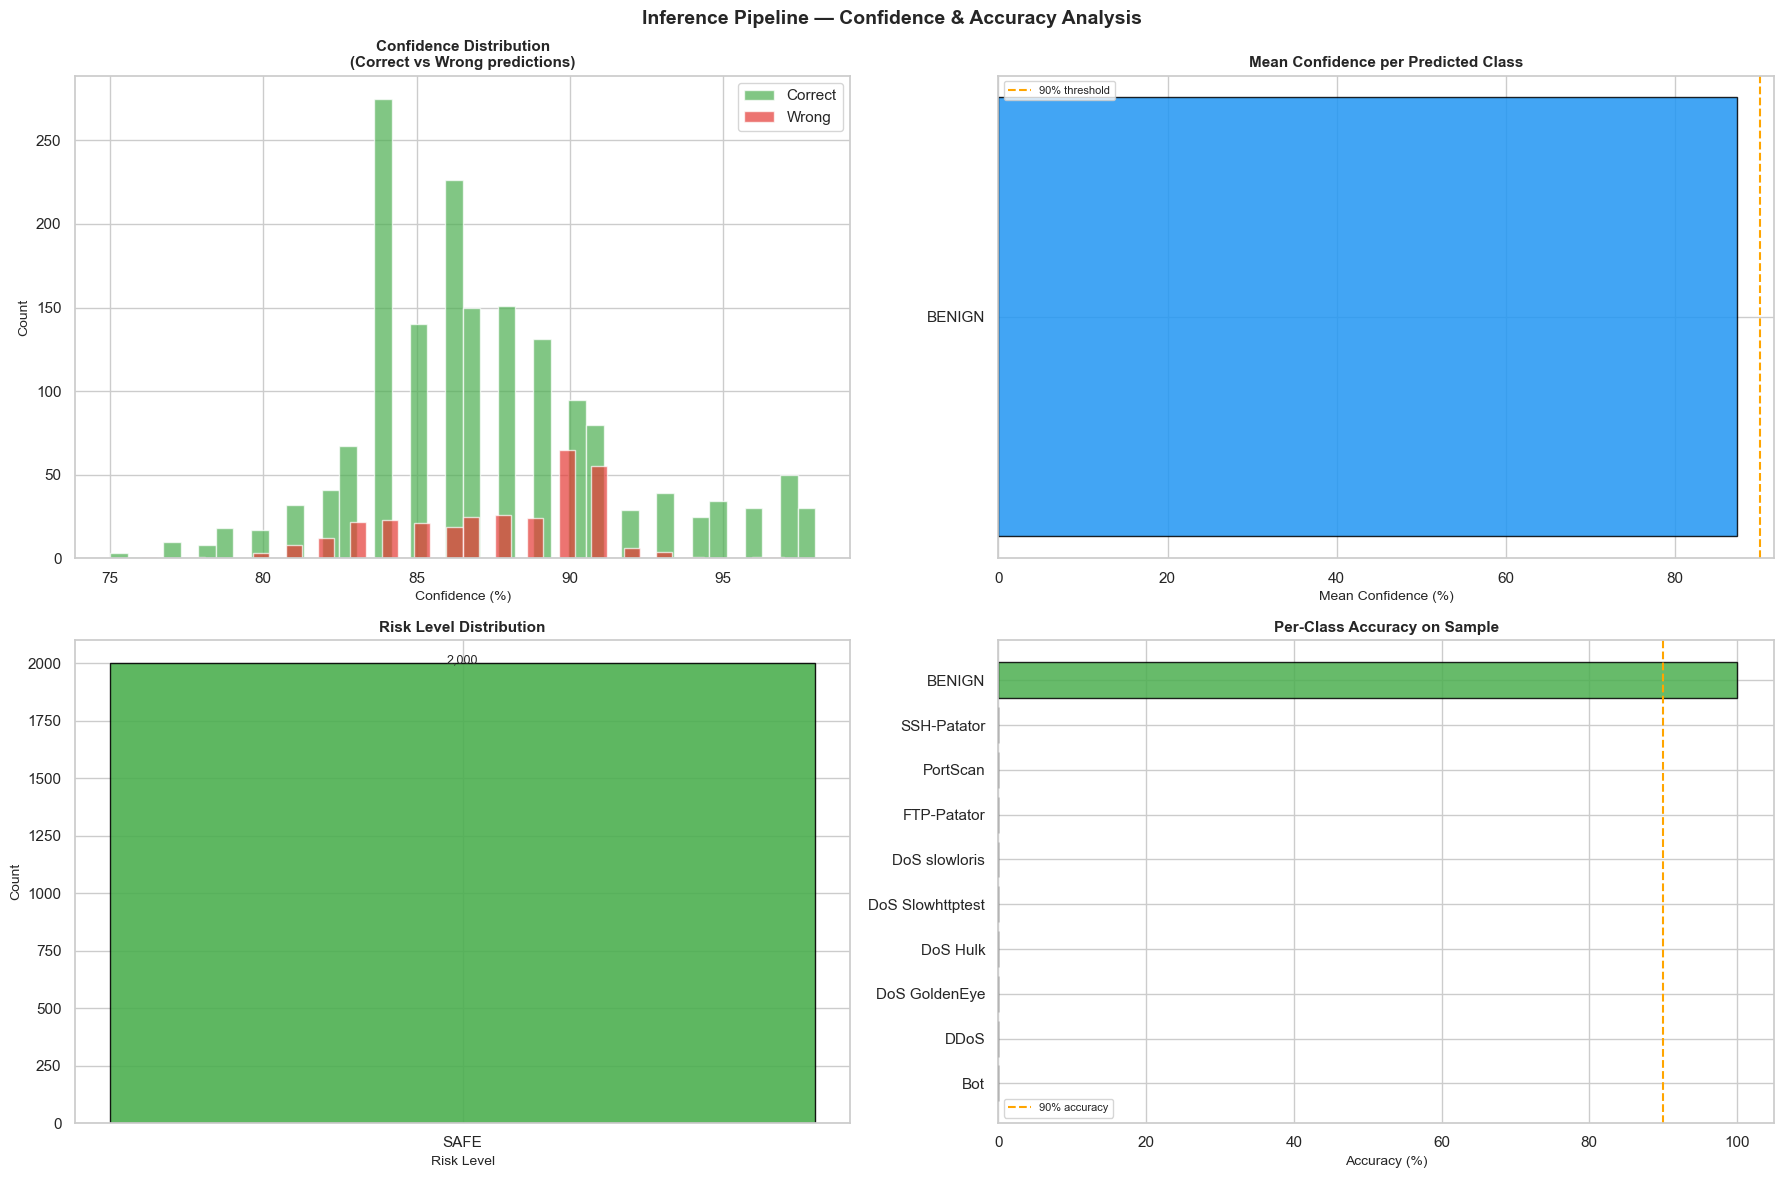

✅ Saved to inference_analysis.png


In [46]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Chart 1: Confidence distribution
axes[0][0].hist(
    vis_results[vis_results['Correct']]['Confidence (%)'],
    bins=40, alpha=0.7, color='#4CAF50',
    label='Correct', edgecolor='white'
)
axes[0][0].hist(
    vis_results[~vis_results['Correct']]['Confidence (%)'],
    bins=40, alpha=0.7, color='#E53935',
    label='Wrong', edgecolor='white'
)
axes[0][0].set_xlabel('Confidence (%)')
axes[0][0].set_ylabel('Count')
axes[0][0].set_title('Confidence Distribution\n(Correct vs Wrong predictions)',
                     fontweight='bold')
axes[0][0].legend()

# ── Chart 2: Confidence by predicted class
conf_by_class = vis_results.groupby('Predicted_Label')['Confidence (%)'].mean()\
                            .sort_values(ascending=True)
colors = ['#E53935' if c != 'BENIGN' else '#2196F3'
          for c in conf_by_class.index]
axes[0][1].barh(conf_by_class.index, conf_by_class.values,
                color=colors, edgecolor='black', alpha=0.85)
axes[0][1].axvline(90, color='orange', linestyle='--',
                   linewidth=1.5, label='90% threshold')
axes[0][1].set_xlabel('Mean Confidence (%)')
axes[0][1].set_title('Mean Confidence per Predicted Class',
                     fontweight='bold')
axes[0][1].legend(fontsize=8)

# ── Chart 3: Risk level breakdown
risk_counts = vis_results['Risk_Level'].value_counts()
risk_colors = {'SAFE':'#4CAF50','🔴 HIGH':'#E53935',
               '🟠 MEDIUM':'#FF9800','🟡 LOW':'#FFEB3B'}
bar_colors  = [risk_colors.get(r,'#9E9E9E') for r in risk_counts.index]
axes[1][0].bar([str(r) for r in risk_counts.index],
               risk_counts.values,
               color=bar_colors, edgecolor='black', alpha=0.9)
axes[1][0].set_xlabel('Risk Level')
axes[1][0].set_ylabel('Count')
axes[1][0].set_title('Risk Level Distribution', fontweight='bold')
for bar, val in zip(axes[1][0].patches, risk_counts.values):
    axes[1][0].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+2,
                   f'{int(val):,}', ha='center', fontsize=9)

# ── Chart 4: Accuracy per class
acc_by_class = vis_results.groupby('True_Label')['Correct']\
                           .mean().sort_values() * 100
colors4 = ['#E53935' if v < 80 else '#4CAF50' for v in acc_by_class.values]
axes[1][1].barh(acc_by_class.index, acc_by_class.values,
                color=colors4, edgecolor='black', alpha=0.85)
axes[1][1].axvline(90, color='orange', linestyle='--',
                   linewidth=1.5, label='90% accuracy')
axes[1][1].set_xlabel('Accuracy (%)')
axes[1][1].set_title('Per-Class Accuracy on Sample',
                     fontweight='bold')
axes[1][1].legend(fontsize=8)

plt.suptitle('Inference Pipeline — Confidence & Accuracy Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('inference_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved to inference_analysis.png')


In [44]:
import os
from sklearn.metrics import classification_report
import joblib

SAVE_DIR = 'inference_results'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 1. Save predictions CSV
results_csv.to_csv(f'{SAVE_DIR}/predictions.csv', index=False)
print(f'✅ Predictions saved : {SAVE_DIR}/predictions.csv  ({len(results_csv):,} rows)')

# ── 2. Save attack-only predictions
attacks_only = results_csv[results_csv['Is_Attack'] == 1]
attacks_only.to_csv(f'{SAVE_DIR}/attacks_only.csv', index=False)
print(f'✅ Attacks only saved: {SAVE_DIR}/attacks_only.csv  ({len(attacks_only):,} rows)')

# ── 3. Save classification report as CSV
report_dict = classification_report(
    true_enc, pred_enc,
    target_names=CLASS_NAMES,
    zero_division=0,
    output_dict=True        # returns dict instead of string
)
report_df = pd.DataFrame(report_dict).T.round(4)
report_df.to_csv(f'{SAVE_DIR}/classification_report.csv')
print(f'✅ Classification report saved: {SAVE_DIR}/classification_report.csv')

# ── 4. Save summary metrics as CSV
summary_metrics = {
    'Metric'  : ['Accuracy','Macro F1','Weighted F1',
                 'Total Flows','Benign Flows','Attack Flows',
                 'Benign %','Attack %'],
    'Value'   : [
        round(acc*100, 3),
        round(f1m*100, 3),
        round(f1w*100, 3),
        int(total),
        int(n_ben),
        int(n_atk),
        round(n_ben/total*100, 2),
        round(n_atk/total*100, 2),
    ]
}
pd.DataFrame(summary_metrics).to_csv(
    f'{SAVE_DIR}/summary_metrics.csv', index=False
)
print(f'✅ Summary metrics saved: {SAVE_DIR}/summary_metrics.csv')

# ── 5. Save attack breakdown CSV
atk_breakdown = results_csv[results_csv['Is_Attack']==1]\
                    ['Predicted_Label'].value_counts()\
                    .reset_index()
atk_breakdown.columns = ['Attack_Type', 'Count']
atk_breakdown['Percentage (%)'] = (
    atk_breakdown['Count'] / n_atk * 100
).round(2)
atk_breakdown.to_csv(f'{SAVE_DIR}/attack_breakdown.csv', index=False)
print(f'✅ Attack breakdown saved: {SAVE_DIR}/attack_breakdown.csv')

# ── 6. Save complete inference pipeline bundle
pipeline_bundle = {
    'model'        : model,
    'scaler'       : scaler,
    'label_encoder': le,
    'feature_cols' : FEATURE_COLS,
    'log_features' : log_features,
    'class_names'  : CLASS_NAMES,
    'n_classes'    : N_CLASSES,
    'model_type'   : 'Random Forest (Tuned)',
    'dataset'      : 'CIC-IDS2017',
}
joblib.dump(pipeline_bundle,
            f'{SAVE_DIR}/cicids2017_inference_pipeline.pkl')
print(f'✅ Pipeline bundle saved: {SAVE_DIR}/cicids2017_inference_pipeline.pkl')

# ── Final summary
print(f'\n{"="*50}')
print(f'  ALL FILES SAVED TO: {SAVE_DIR}/')
print(f'{"="*50}')
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f'{SAVE_DIR}/{f}') / 1024
    print(f'  {f:<45} {size:,.1f} KB')
print(f'{"="*50}')

✅ Predictions saved : inference_results/predictions.csv  (2,830,744 rows)
✅ Attacks only saved: inference_results/attacks_only.csv  (553,968 rows)
✅ Classification report saved: inference_results/classification_report.csv
✅ Summary metrics saved: inference_results/summary_metrics.csv
✅ Attack breakdown saved: inference_results/attack_breakdown.csv
✅ Pipeline bundle saved: inference_results/cicids2017_inference_pipeline.pkl

  ALL FILES SAVED TO: inference_results/
  attack_breakdown.csv                          0.4 KB
  attacks_only.csv                              48,382.6 KB
  cicids2017_inference_pipeline.pkl             67,958.7 KB
  classification_report.csv                     0.8 KB
  predictions.csv                               232,674.8 KB
  summary_metrics.csv                           0.2 KB
